In [1]:
import pandas as pd

# Load the original events CSV file
events_df = pd.read_csv('events.csv')

# Filter only the transaction (sales) events
sales_df = events_df[events_df['event'] == 'transaction']

# (Optional) Keep only relevant columns
sales_df = sales_df[['timestamp', 'visitorid', 'itemid', 'event']]

# Save the filtered data to a new CSV file
sales_df.to_csv('sales_events.csv', index=False)

print(f"Filtered {len(sales_df)} sales events.")


Filtered 22457 sales events.


In [2]:
import pandas as pd

# Load the filtered sales data
sales_df = pd.read_csv('sales_events.csv')

# Group by itemid and count how many times each item was sold
product_sales = sales_df.groupby('itemid').size().reset_index(name='quantity_sold')

# Sort by quantity sold (optional)
product_sales = product_sales.sort_values(by='quantity_sold', ascending=False)

# Save to a new CSV file
product_sales.to_csv('product_quantity_sold.csv', index=False)

print(product_sales.head())


       itemid  quantity_sold
11898  461686            133
3055   119736             97
5436   213834             92
8064   312728             46
185      7943             46


In [6]:
import pandas as pd

# Load sales data
sales_df = pd.read_csv('sales_events.csv')

# Get 4 unique item IDs that were sold
sold_item_ids = sales_df['itemid'].unique()[:10]
sold_item_ids = sold_item_ids.astype(str)  # ensure consistency

# Load both properties files
props1 = pd.read_csv('item_properties_part1.csv')
props2 = pd.read_csv('item_properties_part2.csv')

# Ensure itemid is string in both
props1['itemid'] = props1['itemid'].astype(str)
props2['itemid'] = props2['itemid'].astype(str)

# Filter both files for only the sold itemids
filtered_props1 = props1[props1['itemid'].isin(sold_item_ids)]
filtered_props2 = props2[props2['itemid'].isin(sold_item_ids)]

# Combine and sort by item and timestamp
filtered_props = pd.concat([filtered_props1, filtered_props2], ignore_index=True)
filtered_props = filtered_props.sort_values(by=['itemid', 'timestamp'])
# Convert Unix timestamp to human-readable datetime
filtered_props['readable_time'] = pd.to_datetime(filtered_props['timestamp'], unit='ms')


# Save to CSV
filtered_props.to_csv('properties_for_4_sold_items.csv', index=False)

print("Extracted properties for 4 sold items:")
print(filtered_props.head())


Extracted properties for 4 sold items:
         timestamp  itemid property  \
75   1431226800000  150100      678   
87   1431226800000  150100      283   
105  1431226800000  150100      776   
125  1431226800000  150100      764   
172  1431226800000  150100      888   

                                                 value       readable_time  
75                                              664925 2015-05-10 03:00:00  
87   1249027 664925 1237562 664925 908184 721488 71... 2015-05-10 03:00:00  
105                                             715855 2015-05-10 03:00:00  
125                                            1285872 2015-05-10 03:00:00  
172                                            1237562 2015-05-10 03:00:00  


In [1]:
import pandas as pd

# --- Step 1: Load sales and get top 10 sold items ---
sales_df = pd.read_csv('sales_events.csv')
top_10_items = sales_df['itemid'].value_counts().head(10).index.astype(str).tolist()

# --- Step 2: Load properties files ---
props1 = pd.read_csv('item_properties_part1.csv')
props2 = pd.read_csv('item_properties_part2.csv')

# Ensure itemid is string
props1['itemid'] = props1['itemid'].astype(str)
props2['itemid'] = props2['itemid'].astype(str)

# --- Step 3: Filter for top 10 itemids only ---
filtered_props1 = props1[props1['itemid'].isin(top_10_items)]
filtered_props2 = props2[props2['itemid'].isin(top_10_items)]

# Combine and sort
filtered_props = pd.concat([filtered_props1, filtered_props2], ignore_index=True)
filtered_props = filtered_props.sort_values(by=['itemid', 'timestamp'])

# Add readable timestamp
filtered_props['readable_time'] = pd.to_datetime(filtered_props['timestamp'], unit='ms')

# --- Step 4: Save to file ---
filtered_props.to_csv('properties_for_top10_sold_items.csv', index=False)

print("✅ Extracted properties for top 10 sold items:")
print(filtered_props.head())


✅ Extracted properties for top 10 sold items:
         timestamp  itemid property      value       readable_time
39   1431226800000  119736     1081     769062 2015-05-10 03:00:00
130  1431226800000  119736      678     416431 2015-05-10 03:00:00
170  1431226800000  119736      112     679677 2015-05-10 03:00:00
202  1431226800000  119736      790  n3480.000 2015-05-10 03:00:00
272  1431226800000  119736      159     519769 2015-05-10 03:00:00


now we keep the price as the oly property, code 790


In [2]:
import pandas as pd

# 1. Load the CSV
df = pd.read_csv('properties_for_top10_sold_items.csv')

# 2. Filter rows where 'property' equals '790'
filtered_df = df[df['property'] == '790']

# 3. Save the filtered DataFrame to a new CSV
filtered_df.to_csv('properties_for_4_sold_items_filtered.csv', index=False)


In [3]:
import pandas as pd

# Load the filtered data
df = pd.read_csv('properties_for_10_sold_items_filtered.csv')

# Loop through each unique itemid and save to separate CSV
for item_id in df['itemid'].unique():
    item_df = df[df['itemid'] == item_id]
    item_df.to_csv(f'item_{item_id}.csv', index=False)


we want a cell file with the top 10 sold items only

In [4]:
import pandas as pd

# Load full sales data
sales_df = pd.read_csv('sales_events.csv')

# Identify top 10 sold products
top_10_item_ids = sales_df['itemid'].value_counts().head(10).index.astype(str)

# Convert itemid to string to ensure consistency
sales_df['itemid'] = sales_df['itemid'].astype(str)

# Filter only sales for top 10 products
filtered_sales = sales_df[sales_df['itemid'].isin(top_10_item_ids)]

# Save to new CSV
filtered_sales.to_csv('sales_top10_items.csv', index=False)

print("✅ Saved sales data for top 10 sold items as 'sales_top10_items.csv'")


✅ Saved sales data for top 10 sold items as 'sales_top10_items.csv'


In [5]:
import pandas as pd
import re
import numpy as np

# Load the sales file
sales_df = pd.read_csv('sales_top10_items.csv')

# Step 1: Get the first sale
first_sale = sales_df.iloc[0]
item_id = first_sale['itemid']
sale_time = first_sale['timestamp']

# Step 2: Load the corresponding item property file
item_file = f'item_{item_id}.csv'
item_df = pd.read_csv(item_file)

# Step 3: Loop through timestamps and find the last one < sale_time
price = np.nan
for i in range(1, len(item_df)):
    current_time = item_df.loc[i, 'timestamp']
    if current_time > sale_time:
        prev_value = item_df.loc[i - 1, 'value']
        match = re.search(r'[\d.]+', str(prev_value))
        price = float(match.group()) if match else np.nan
        break

# Step 4: Output result
print(f"Item ID: {item_id}")
print(f"Sale Timestamp: {sale_time}")
print(f"Matched Price: {price}")


Item ID: 7943
Sale Timestamp: 1433202096802
Matched Price: 17880.0


In [6]:
import pandas as pd
import numpy as np
import os
import re

# Load the full sales events file
sales_df = pd.read_csv('sales_top10_items.csv')

# Add empty price column
sales_df['price'] = np.nan

# Loop over all sales rows
for idx, row in sales_df.iterrows():
    item_id = row['itemid']
    sale_time = row['timestamp']
    item_file = f'item_{item_id}.csv'

    if not os.path.exists(item_file):
        continue  # Skip if the item file doesn't exist

    item_df = pd.read_csv(item_file)

    # Loop through timestamps as you described
    for i in range(1, len(item_df)):
        if item_df.loc[i, 'timestamp'] > sale_time:
            prev_value = item_df.loc[i - 1, 'value']
            match = re.search(r'[\d.]+', str(prev_value))
            price = float(match.group()) if match else np.nan
            sales_df.at[idx, 'price'] = price
            break

# Save the updated DataFrame
sales_df.to_csv('sales_with_price.csv', index=False)


In [7]:
# Drop rows where 'price' is NaN
sales_df = sales_df.dropna(subset=['price'])

# Save the cleaned version
sales_df.to_csv('sales_with_price_cleaned.csv', index=False)


weekly summary

In [8]:
import pandas as pd

# Load and prepare the data
df = pd.read_csv('sales_with_price_cleaned.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df['week'] = df['timestamp'].dt.to_period('W').apply(lambda r: r.start_time)

# Group by item and week
weekly_summary = df.groupby(['itemid', 'week']).agg(
    avg_price=('price', 'mean'),
    quantity_sold=('itemid', 'count')
).reset_index()

# Sort for proper percentage change calculation
weekly_summary = weekly_summary.sort_values(by=['itemid', 'week'])

# Compute percentage change in average price (by item)
weekly_summary['pct_price_change'] = weekly_summary.groupby('itemid')['avg_price'].pct_change() * 100

# Optional: Save to CSV
weekly_summary.to_csv('weekly_price_change_summary.csv', index=False)

# Preview result
print(weekly_summary.head(10))


   itemid       week  avg_price  quantity_sold  pct_price_change
0    7943 2015-05-04    17880.0              6               NaN
1    7943 2015-05-11    17880.0              4               0.0
2    7943 2015-05-18    17880.0              3               0.0
3    7943 2015-05-25    17880.0              4               0.0
4    7943 2015-06-01    17880.0              5               0.0
5    7943 2015-06-08    17880.0              1               0.0
6    7943 2015-06-15    17880.0              2               0.0
7    7943 2015-06-22    17880.0              4               0.0
8    7943 2015-06-29    17880.0              2               0.0
9    7943 2015-07-06    17880.0              1               0.0


visual rep

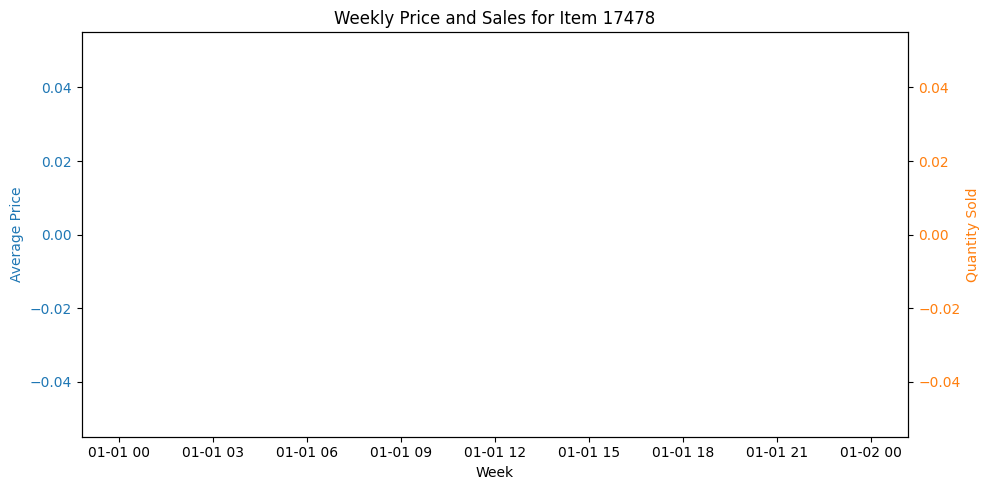

In [10]:
import matplotlib.pyplot as plt

# Choose an item to visualize (we will loop later)
item_id = '17478'  # replace with any item ID from your data

# Filter summary for the chosen item
item_data = weekly_summary[weekly_summary['itemid'] == item_id]

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Price line (left y-axis)
ax1.set_title(f"Weekly Price and Sales for Item {item_id}")
ax1.set_xlabel('Week')
ax1.set_ylabel('Average Price', color='tab:blue')
ax1.plot(item_data['week'], item_data['avg_price'], color='tab:blue', label='Avg Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Sales volume line (right y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Quantity Sold', color='tab:orange')
ax2.plot(item_data['week'], item_data['quantity_sold'], color='tab:orange', linestyle='--', label='Quantity Sold')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Show it
plt.tight_layout()
plt.show()


monthly summary


In [3]:
import pandas as pd

# Load your cleaned sales+price data
df = pd.read_csv('sales_with_price_cleaned.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# Create 'month' column (start of each month)
df['month'] = df['timestamp'].dt.to_period('M').dt.to_timestamp()

# Group by item and month
monthly_summary = df.groupby(['itemid', 'month']).agg(
    avg_price=('price', 'mean'),
    quantity_sold=('itemid', 'count')
).reset_index()

# Sort for calculating % change
monthly_summary = monthly_summary.sort_values(by=['itemid', 'month'])

# Compute month-to-month percentage change in price per item
monthly_summary['pct_price_change'] = monthly_summary.groupby('itemid')['avg_price'].pct_change() * 100

# Save to CSV (optional)
monthly_summary.to_csv('monthly_price_quantity_summary.csv', index=False)

# Preview
print(monthly_summary.head(10))


   itemid      month     avg_price  quantity_sold  pct_price_change
0    7943 2015-05-01  17880.000000             17               NaN
1    7943 2015-06-01  17880.000000             13          0.000000
2    7943 2015-07-01  18780.000000              6          5.033557
3    7943 2015-08-01  20640.000000              4          9.904153
4    7943 2015-09-01  25880.000000              3         25.387597
5   17478 2015-05-01  13280.000000              9               NaN
6   17478 2015-06-01  12683.076923             13         -4.494903
7   17478 2015-07-01  13176.000000             10          3.886463
8   17478 2015-08-01  13440.000000              5          2.003643
9   48030 2015-06-01  20617.500000             16               NaN


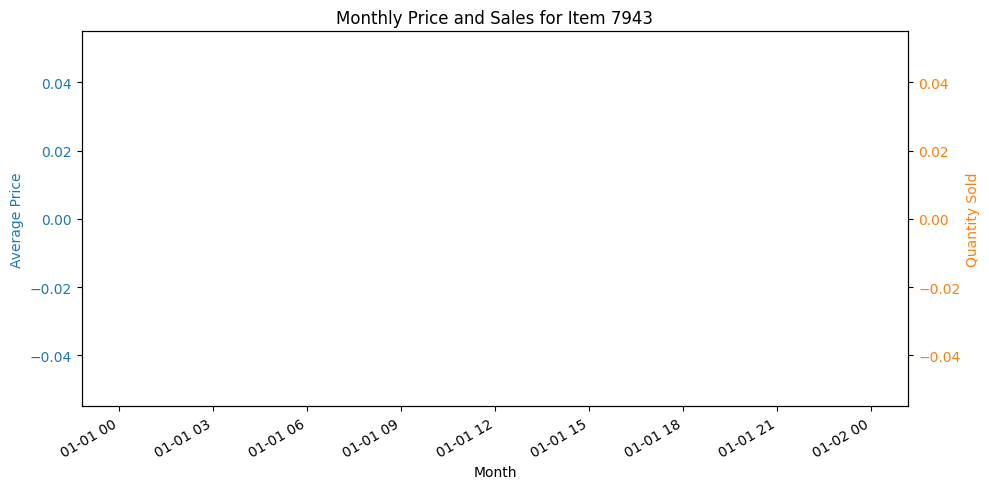

In [12]:
import matplotlib.pyplot as plt

# Choose an item to visualize (you can loop through all later)
item_id = '7943'  # Replace with any item ID from your top 10

# Filter the monthly summary for the chosen item
item_data = monthly_summary[monthly_summary['itemid'] == item_id]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot average price on left Y-axis
ax1.set_title(f"Monthly Price and Sales for Item {item_id}")
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Price', color='tab:blue')
ax1.plot(item_data['month'], item_data['avg_price'], marker='o', color='tab:blue', label='Avg Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot quantity sold on right Y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Quantity Sold', color='tab:orange')
ax2.plot(item_data['month'], item_data['quantity_sold'], marker='s', linestyle='--', color='tab:orange', label='Quantity Sold')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Improve layout
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


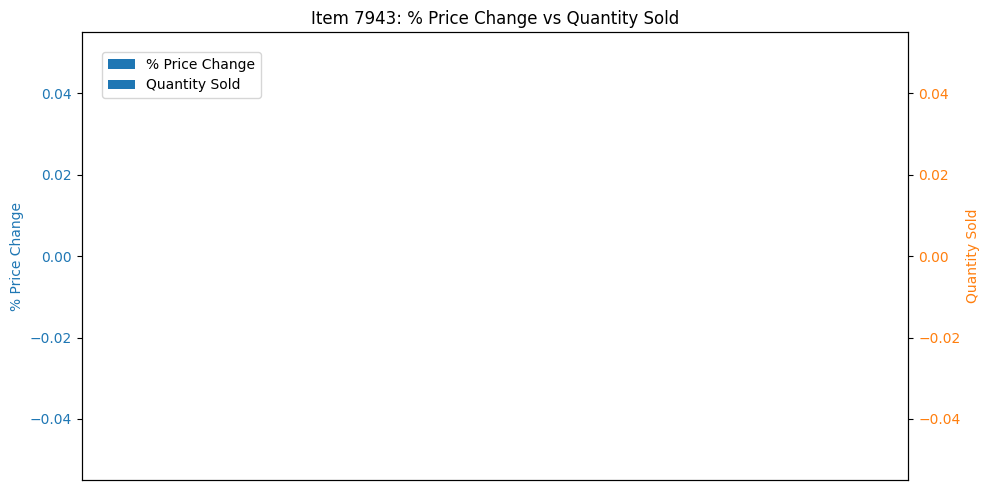

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Filter monthly data for one item
item_id = '7943'
item_data = monthly_summary[monthly_summary['itemid'] == item_id].copy()

# Drop the first row (NaN % change)
item_data = item_data.dropna(subset=['pct_price_change'])

# Create x-axis positions
x = np.arange(len(item_data))
width = 0.35  # bar width

# Plot setup
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Bar plot for % price change
ax1.bar(x - width/2, item_data['pct_price_change'], width, color='tab:blue', label='% Price Change')
ax1.set_ylabel('% Price Change', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Bar plot for quantity sold
ax2.bar(x + width/2, item_data['quantity_sold'], width, color='tab:orange', label='Quantity Sold')
ax2.set_ylabel('Quantity Sold', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Set common x-ticks as month labels
months = item_data['month'].dt.strftime('%Y-%m')
plt.xticks(x, months, rotation=45)
plt.title(f"Item {item_id}: % Price Change vs Quantity Sold")

# Combine legends
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


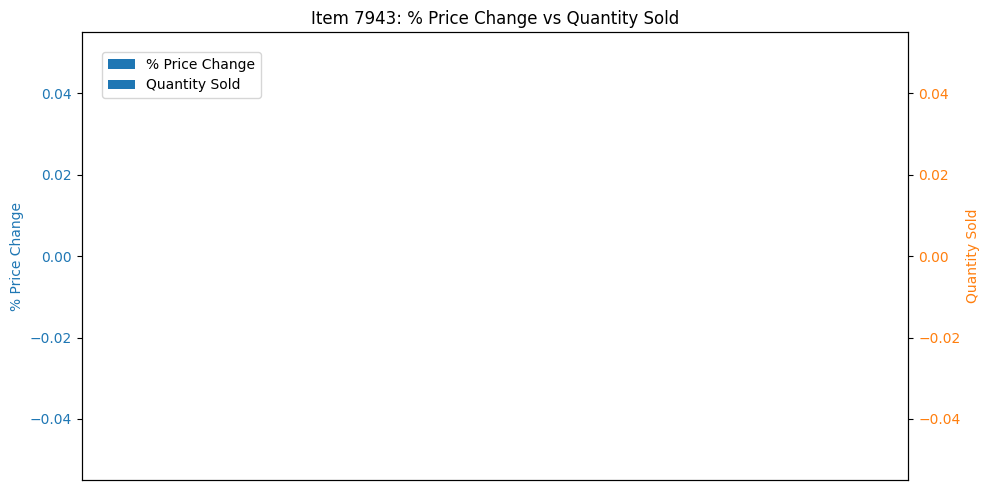

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for one item
item_id = '7943'
item_data = monthly_summary[monthly_summary['itemid'] == item_id].copy()

# Fill NaN price changes with 0
item_data['pct_price_change'] = item_data['pct_price_change'].fillna(0)

# Create x positions
x = np.arange(len(item_data))
width = 0.35

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(x - width/2, item_data['pct_price_change'], width, color='tab:blue', label='% Price Change')
ax1.set_ylabel('% Price Change', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2.bar(x + width/2, item_data['quantity_sold'], width, color='tab:orange', label='Quantity Sold')
ax2.set_ylabel('Quantity Sold', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# X-axis labels
months = item_data['month'].dt.strftime('%Y-%m')
plt.xticks(x, months, rotation=45)
plt.title(f"Item {item_id}: % Price Change vs Quantity Sold")

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


In [4]:
import matplotlib.pyplot as plt

# Select one item
item_id = '7943'
item_data = monthly_summary[monthly_summary['itemid'] == item_id].copy()

# Calculate % change in quantity sold
item_data['pct_quantity_change'] = item_data['quantity_sold'].pct_change() * 100

# Fill NaNs with 0 for first row
item_data['pct_price_change'] = item_data['pct_price_change'].fillna(0)
item_data['pct_quantity_change'] = item_data['pct_quantity_change'].fillna(0)

# Plot setup
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Line chart for % price change
ax1.plot(item_data['month'], item_data['pct_price_change'], color='tab:blue', marker='o', label='% Price Change')
ax1.set_ylabel('% Price Change', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Line chart for % quantity change
ax2.plot(item_data['month'], item_data['pct_quantity_change'], color='tab:orange', marker='s', linestyle='--', label='% Quantity Change')
ax2.set_ylabel('% Quantity Change', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Labels and layout
plt.title(f"Monthly % Change - Price vs Quantity Sold (Item {item_id})")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()


ValueError: attempt to get argmax of an empty sequence